In [1]:
import pandas as pd

appearances = pd.read_csv('data/appearances.csv')
print("Rows:", len(appearances))
print(appearances.head())

Rows: 1877839
    appearance_id  game_id  player_id  player_club_id  player_current_club_id  \
0   2231978_38004  2231978      38004             853                     235   
1   2233748_79232  2233748      79232            8841                    2698   
2   2234413_42792  2234413      42792            6251                     465   
3   2234418_73333  2234418      73333            1274                      76   
4  2234421_122011  2234421     122011             195                    3008   

         date       player_name competition_id  yellow_cards  red_cards  \
0  2012-07-03  Aurélien Joachim            CLQ             0          0   
1  2012-07-05    Ruslan Abyshov            ELQ             0          0   
2  2012-07-05       Sander Puri            ELQ             0          0   
3  2012-07-05   Vegar Hedenstad            ELQ             0          0   
4  2012-07-05  Markus Henriksen            ELQ             0          0   

   goals  assists  minutes_played  
0      2    

In [2]:
players = pd.read_csv('data/players.csv')
clubs   = pd.read_csv('data/clubs.csv')
games   = pd.read_csv('data/games.csv')

print("=== PLAYERS ===")
print(players.shape)
print(players.columns.tolist())

print("\n=== CLUBS ===")
print(clubs.shape)
print(clubs.columns.tolist())

print("\n=== GAMES ===")
print(games.shape)
print(games.columns.tolist())

=== PLAYERS ===
(47637, 26)
['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']

=== CLUBS ===
(796, 17)
['club_id', 'club_code', 'name', 'domestic_competition_id', 'total_market_value', 'squad_size', 'average_age', 'foreigners_number', 'foreigners_percentage', 'national_team_players', 'stadium_name', 'stadium_seats', 'net_transfer_record', 'coach_name', 'last_season', 'filename', 'url']

=== GAMES ===
(88271, 23)
['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away

In [3]:
# Filter for Premier League only (competition_id = 'GB1')
pl_appearances = appearances[appearances['competition_id'] == 'GB1']
print("Premier League appearances:", len(pl_appearances))

# Check what seasons are available
print("\nSeasons available:")
print(sorted(pl_appearances['date'].str[:4].unique()))

Premier League appearances: 148751

Seasons available:
['2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']


In [5]:
# Make a clean independent copy first (fixes the warning)
pl_appearances = appearances[appearances['competition_id'] == 'GB1'].copy()

# Extract year cleanly
pl_appearances['year'] = pl_appearances['date'].str[:4].astype(int)

# Keep 2019 to 2024 only (clean last 5 seasons)
pl_recent = pl_appearances[
    (pl_appearances['year'] >= 2019) & 
    (pl_appearances['year'] <= 2024)
].copy()

print("Rows after filtering:", len(pl_recent))
print("Years included:", sorted(pl_recent['year'].unique()))


Rows after filtering: 64691
Years included: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [6]:
# We only need player_id and position from players.csv
player_positions = players[['player_id', 'name', 'position', 'sub_position']]

# Merge with your filtered appearances
pl_recent = pl_recent.merge(player_positions, on='player_id', how='left')

print("Columns now available:")
print(pl_recent.columns.tolist())

print("\nPosition values in the data:")
print(pl_recent['position'].value_counts())

Columns now available:
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played', 'year', 'name', 'position', 'sub_position']

Position values in the data:
position
Defender      21671
Midfield      19750
Attack        18684
Goalkeeper     4586
Name: count, dtype: int64


In [7]:
# Count how many times each player appeared for each club
loyalty = pl_recent.groupby(
    ['player_id', 'name', 'player_club_id', 'position']
)['appearance_id'].count().reset_index()

# Rename the count column to something clear
loyalty.columns = ['player_id', 'player_name', 'club_id', 'position', 'appearances']

# Sort by appearances descending so most loyal players are at top
loyalty = loyalty.sort_values('appearances', ascending=False)

print("Shape:", loyalty.shape)
print("\nTop 10 most appeared players:")
print(loyalty.head(10))

Shape: (1689, 5)

Top 10 most appeared players:
     player_id             player_name  club_id    position  appearances
437     130164         Jordan Pickford       29  Goalkeeper          215
494     148455           Mohamed Salah       31      Attack          212
715     238223                 Ederson      281  Goalkeeper          207
309      91845           Heung-min Son      148      Attack          205
886     314353  Trent Alexander-Arnold       31    Defender          202
487     148153              Lewis Dunk     1237    Defender          200
722     241641          Bernardo Silva      281    Midfield          198
709     234803        Andrew Robertson       31    Defender          195
783     258923         Marcus Rashford      985      Attack          192
341     105470                 Alisson       31  Goalkeeper          191


In [8]:
# Average appearances per position
loyalty_by_position = loyalty.groupby('position')['appearances'].agg(
    avg_appearances='mean',
    median_appearances='median',
    total_players='count'
).round(2).sort_values('avg_appearances', ascending=False)

print("=== LOYALTY BY POSITION ===")
print(loyalty_by_position)

=== LOYALTY BY POSITION ===
            avg_appearances  median_appearances  total_players
position                                                      
Midfield              39.66                23.0            498
Defender              39.19                25.0            553
Attack                37.07                21.0            504
Goalkeeper            34.22                14.0            134


C:\Users\manav\AppData\Local\Temp\ipykernel_5188\1683322333.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=loyalty, x='position', y='appearances',


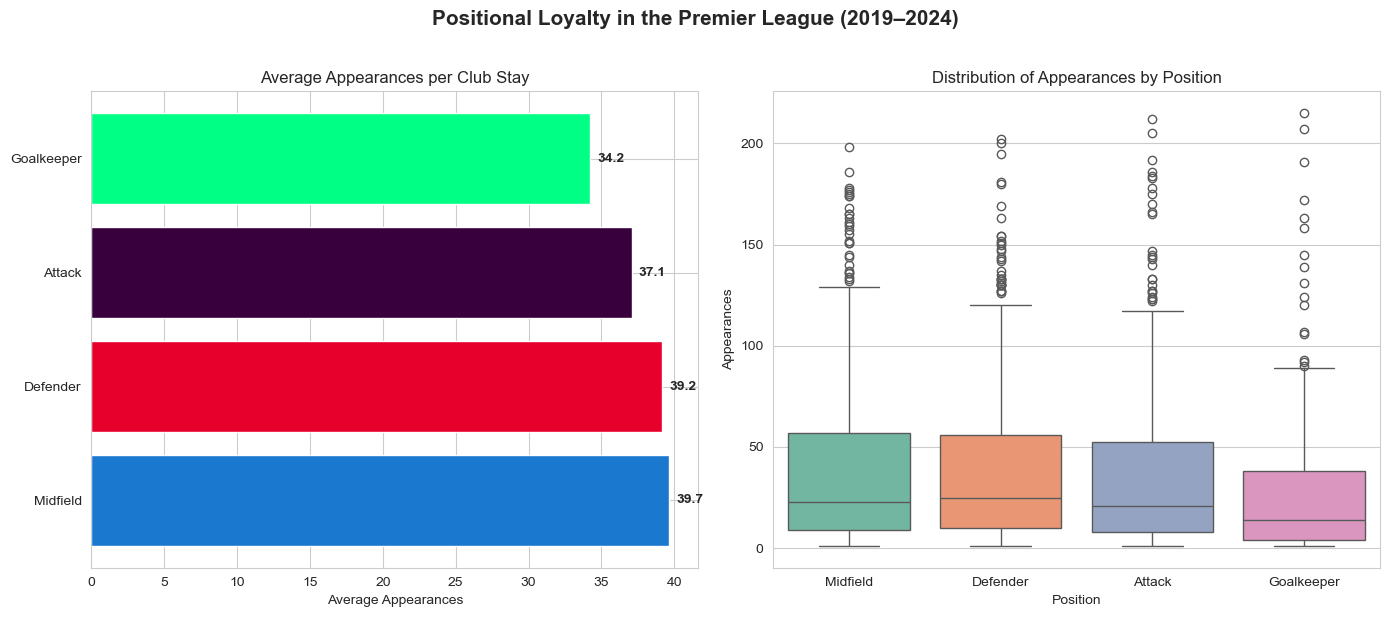

Chart saved!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Positional Loyalty in the Premier League (2019–2024)", 
             fontsize=15, fontweight='bold', y=1.02)

# Chart 1 — Average appearances bar chart
position_order = loyalty_by_position.index.tolist()
avg_vals = loyalty_by_position['avg_appearances'].values

axes[0].barh(position_order, avg_vals, color=['#1a78cf','#e8002d','#38003c','#00ff85'])
axes[0].set_xlabel("Average Appearances")
axes[0].set_title("Average Appearances per Club Stay")
for i, v in enumerate(avg_vals):
    axes[0].text(v + 0.5, i, str(round(v, 1)), va='center', fontweight='bold')

# Chart 2 — Box plot showing spread
sns.boxplot(data=loyalty, x='position', y='appearances', 
            order=position_order, ax=axes[1], palette='Set2')
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Appearances")
axes[1].set_title("Distribution of Appearances by Position")

plt.tight_layout()
plt.savefig('loyalty_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

               player_name    position  appearances
0          Jordan Pickford  Goalkeeper          215
1            Mohamed Salah      Attack          212
2                  Ederson  Goalkeeper          207
3            Heung-min Son      Attack          205
4   Trent Alexander-Arnold    Defender          202
5               Lewis Dunk    Defender          200
6           Bernardo Silva    Midfield          198
7         Andrew Robertson    Defender          195
8          Marcus Rashford      Attack          192
9                  Alisson  Goalkeeper          191
10             John McGinn    Midfield          186
11             Bukayo Saka      Attack          186
12          Miguel Almirón      Attack          184
13         Virgil van Dijk    Defender          181
14              Ezri Konsa    Defender          180
15             Pascal Groß    Midfield          178
16         Bruno Fernandes    Midfield          177
17            Tomáš Souček    Midfield          176
18        Lu

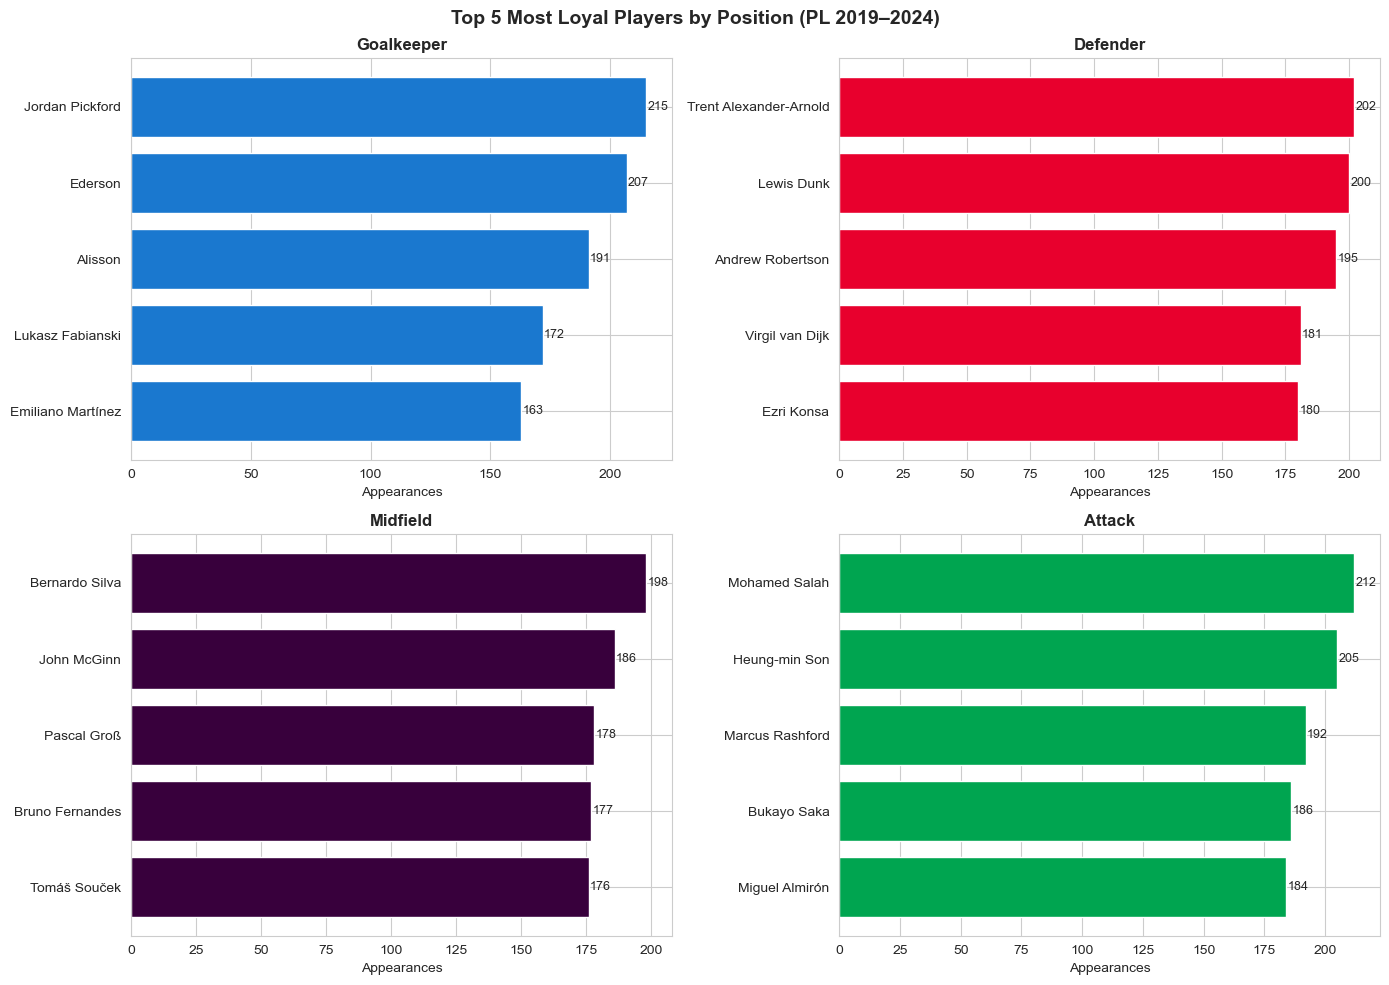

Chart saved!


In [13]:
import matplotlib.pyplot as plt

# Get top 5 players per position by appearances
top5 = (
    loyalty.sort_values('appearances', ascending=False)
    .groupby('position')
    .head(5)
    .reset_index(drop=True)
)

print(top5[['player_name', 'position', 'appearances']])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 5 Most Loyal Players by Position (PL 2019–2024)", 
             fontsize=14, fontweight='bold')

positions = ['Goalkeeper', 'Defender', 'Midfield', 'Attack']
colors = ['#1a78cf', '#e8002d', '#38003c', '#00a550']
ax_flat = axes.flatten()

for i, pos in enumerate(positions):
    data = top5[top5['position'] == pos].sort_values('appearances')
    ax_flat[i].barh(data['player_name'], data['appearances'], color=colors[i])
    ax_flat[i].set_title(pos, fontweight='bold')
    ax_flat[i].set_xlabel("Appearances")
    for j, v in enumerate(data['appearances']):
        ax_flat[i].text(v + 0.5, j, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top5_loyal_players.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Key Findings

This analysis looked at 64,691 Premier League appearances across 1,689 
player-club stints between 2019 and 2024 to understand which positions 
show the most loyalty to their clubs.

### Results by Average Appearances per Club Stay:
| Position   | Avg Appearances |
|------------|----------------|
| Midfield   | 39.7           |
| Defender   | 39.2           |
| Attack     | 37.1           |
| Goalkeeper | 34.2           |

### Insights:
- **Midfielders are the most loyal** position in the Premier League, 
  averaging 39.7 appearances per club stay — the highest of all positions.
- **Defenders are close behind** at 39.2, suggesting that defensive 
  stability is valued by clubs and players alike.
- **Goalkeepers are surprisingly the least loyal** at 34.2 average 
  appearances, contrary to the common belief that keepers are long-term 
  fixtures at clubs.
- **Mohamed Salah** leads all outfield players with 212 appearances for 
  Liverpool, while **Jordan Pickford** tops the goalkeeper category with 
  215 appearances for Everton.
- The box plots reveal high variance in every position — every group has 
  outlier players who stayed for nearly the entire 5-season period.

### Limitations:
- "Loyalty" here is measured purely by appearances, not contract length 
  or transfer attempts.
- Players who joined or left mid-period naturally have fewer appearances, 
  which may slightly lower averages.